**Step 1: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Import Required Libraries**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 3: Define Paths for the LeftFace(VS) Dataset**

Here i will process only the LeftFace(VS) folder for DownSyndrome and Healthy.

In [ ]:
#Defining source and destination paths for LeftFace(VS) part
source_dir = '/content/drive/My Drive/Face_Fea_Extract'
destination_dir = '/content/drive/My Drive/FaceClassificationData/LeftFace(VS)'


classes = {"DownSyndrome": "1", "Healthy": "0"}

#Creating Train and Val directories/folders for LeftFace(VS)
for split in ['Train', 'Val']:
    for class_label in classes.values():
        os.makedirs(os.path.join(destination_dir, split, class_label), exist_ok=True)

print("Directory structure for LeftFace(VS) created successfully!")

Directory structure for LeftFace(VS) created successfully!


**Step 4: Dataset Splitting for LeftFace(VS)**

This step will split the Left Face(VS) dataset into Train and Val for both classes.

In [ ]:
#Splitting and organize LeftFace(VS) data
for class_name, label in classes.items():
    #The Path to the LeftFace(VS) folder for each class
    class_path = os.path.join(source_dir, class_name, 'LeftFace(VS)')
    all_images = []

    # Collecting all images from LeftFace(VS) folder
    for file in os.listdir(class_path):
        if file.endswith(('.jpg', '.png')):
            all_images.append(os.path.join(class_path, file))

    #Splitting into Train and Val
    train_images, val_images = train_test_split(all_images, train_size=0.8, random_state=42)

    #Copying files to Train and Val directories
    for img in train_images:
        shutil.copy(img, os.path.join(destination_dir, 'Train', label))
    for img in val_images:
        shutil.copy(img, os.path.join(destination_dir, 'Val', label))

print("LeftFace(VS) dataset split and organized successfully!")

LeftFace(VS) dataset split and organized successfully!


**Step 5: Verify Folder Contents**

In [ ]:
#Verifying Train folder for Healthy
!ls '/content/drive/My Drive/FaceClassificationData/LeftFace(VS)/Train/0'

#Verifying Train folder for DownSyndrome
!ls '/content/drive/My Drive/FaceClassificationData/LeftFace(VS)/Train/1'

'LeftFace(VS)_healty_1000.jpg'	'LeftFace(VS)_healty_1442.jpg'	'LeftFace(VS)_healty_564.jpg'
'LeftFace(VS)_healty_1001.jpg'	'LeftFace(VS)_healty_1443.jpg'	'LeftFace(VS)_healty_565.jpg'
'LeftFace(VS)_healty_1003.jpg'	'LeftFace(VS)_healty_1445.jpg'	'LeftFace(VS)_healty_566.jpg'
'LeftFace(VS)_healty_1004.jpg'	'LeftFace(VS)_healty_1446.jpg'	'LeftFace(VS)_healty_568.jpg'
'LeftFace(VS)_healty_1005.jpg'	'LeftFace(VS)_healty_1447.jpg'	'LeftFace(VS)_healty_569.jpg'
'LeftFace(VS)_healty_1006.jpg'	'LeftFace(VS)_healty_1449.jpg'	'LeftFace(VS)_healty_56.jpg'
'LeftFace(VS)_healty_1007.jpg'	'LeftFace(VS)_healty_144.jpg'	'LeftFace(VS)_healty_570.jpg'
'LeftFace(VS)_healty_1009.jpg'	'LeftFace(VS)_healty_1450.jpg'	'LeftFace(VS)_healty_571.jpg'
'LeftFace(VS)_healty_100.jpg'	'LeftFace(VS)_healty_1451.jpg'	'LeftFace(VS)_healty_573.jpg'
'LeftFace(VS)_healty_1010.jpg'	'LeftFace(VS)_healty_1452.jpg'	'LeftFace(VS)_healty_574.jpg'
'LeftFace(VS)_healty_1011.jpg'	'LeftFace(VS)_healty_1453.jpg'	'LeftFace(VS)_healty_

**Step 6: Visualize Sample Images**

Healthy LeftFace(VS) - Train:


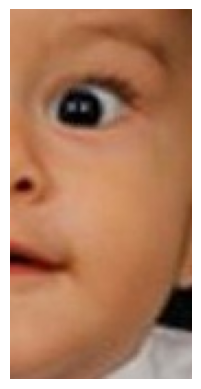

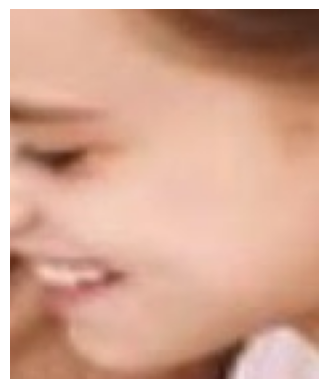

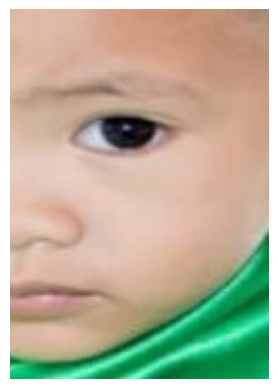

Down Syndrome LeftFace(VS) - Train:


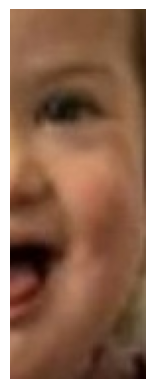

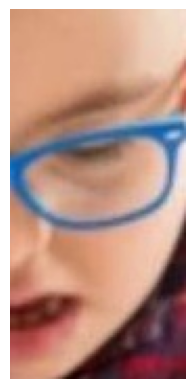

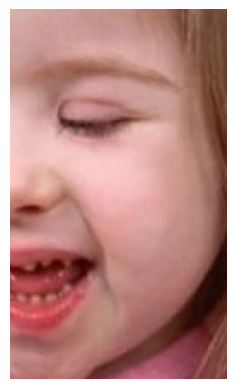

In [ ]:
#Function to display sample images
def display_samples(path, num_samples=3):
    images = [os.path.join(path, img) for img in os.listdir(path)[:num_samples]]
    for img_path in images:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

#Displaying samples for Healthy LeftFace(VS)
print("Healthy LeftFace(VS) - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/LeftFace(VS)/Train/0')

#Displaying samples for DownSyndrome LeftFace(VS)
print("Down Syndrome LeftFace(VS) - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/LeftFace(VS)/Train/1')

**Step 7: Install YOLO Framework**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.3/896.3 kB 11.3 MB/s eta 0:00:00


**Step 8: Train YOLO Model**

In [ ]:
from ultralytics import YOLO

#Loading YOLO model
model = YOLO("yolo11n-cls.pt")  #checkpoint

#Training the model using the corrected LeftFace(VS) dataset
results = model.train(
    data='/content/drive/My Drive/FaceClassificationData/LeftFace(VS)',  #Dataset path
    epochs=20,                  # Number of epochs
    imgsz=224,                  # Image size
    batch=16,                   # Batch size
    project="FaceClassificationResults/LeftFace(VS)"  #Saving results in my specified folder
)

print("Training completed successfully!")

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=/content/drive/My Drive/FaceClassificationData/LeftFace(VS), epochs=20, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=FaceClassificationResults/LeftFace(VS), name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_co

train: Scanning /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/train... 2374 images, 0 corrupt: 100%|██████████| 2374/2374 [00:30<00:00, 79.09it/s] 


train: New cache created: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/train.cache


val: Scanning /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:05<00:00, 108.91it/s]


val: New cache created: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 0 dataloader workers
Logging results to FaceClassificationResults/LeftFace(VS)/train3
Starting training for 20 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

      20/20         0G     0.2151          6        224: 100%|██████████| 149/149 [02:37<00:00,  1.06s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:14<00:00,  1.28it/s]

                   all       0.86          1



20 epochs completed in 0.973 hours.
Optimizer stripped from FaceClassificationResults/LeftFace(VS)/train3/weights/last.pt, 3.2MB
Optimizer stripped from FaceClassificationResults/LeftFace(VS)/train3/weights/best.pt, 3.2MB

Validating FaceClassificationResults/LeftFace(VS)/train3/weights/best.pt...
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val... found 594 images in 2 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:14<00:00,  1.27it/s]


                   all       0.87          1
Speed: 0.0ms preprocess, 13.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/LeftFace(VS)/train3
Training completed successfully!


**Step 9: Validate the Model**

In [ ]:
#Validating the model using the LeftFace(VS) dataset
metrics = model.val()
print("Validation Results for LeftFace(VS):", metrics)

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val... found 594 images in 2 classes ✅ 
test: None...


val: Scanning /content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 38/38 [00:15<00:00,  2.39it/s]


                   all       0.87          1
Speed: 0.0ms preprocess, 14.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/LeftFace(VS)/train32
Validation Results for LeftFace(VS): ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbd610aeda0>
curves: []
curves_results: []
fitness: 0.9351851940155029
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8703703880310059, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9351851940155029}
save_dir: PosixPath('FaceClassificationResults/LeftFace(VS)/train32')
speed: {'preprocess': 0.0015268422136403093, 'inference': 14.692426530600397, 'loss': 0.0003122721456919455, 'postprocess': 0.00016135398787681503}
task: 'classify'
top1: 0.8703703880310059
top5: 1.0


**Step 10: Analyze Predictions and Compute Metrics**

Generate Predictions and Labels

In [ ]:
#Path to validation data for LeftFace(VS)
val_path = '/content/drive/My Drive/FaceClassificationData/LeftFace(VS)/val'

true_labels, predicted_labels = [], []

for class_label in ["0", "1"]:  # Healthy=0, Down Syndrome=1
    class_dir = os.path.join(val_path, class_label)
    for img_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_file)
        prediction = model(img_path, verbose=False)
        probs = prediction[0].probs
        # Use top1 attribute instead of argmax
        predicted_class = probs.top1
        true_labels.append(int(class_label))
        predicted_labels.append(predicted_class)

print("Predictions for LeftFace(VS) completed!")

Predictions for LeftFace(VS) completed!


Calculate and Display Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

#Calculating accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy for LeftFace(VS): {accuracy * 100:.2f}%")

Accuracy for LeftFace(VS): 87.04%


Generate Classification Report

In [ ]:
from sklearn.metrics import classification_report

#Generating classification report
report = classification_report(true_labels, predicted_labels, target_names=["Healthy", "Down Syndrome"])
print("Classification Report for LeftFace(VS):\n", report)

Classification Report for LeftFace(VS):
                precision    recall  f1-score   support

      Healthy       0.90      0.83      0.87       297
Down Syndrome       0.84      0.91      0.88       297

     accuracy                           0.87       594
    macro avg       0.87      0.87      0.87       594
 weighted avg       0.87      0.87      0.87       594



Generate Confusion Matrix

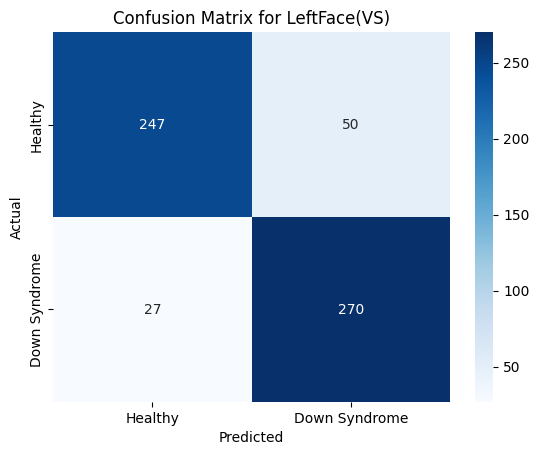

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Generating confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

#Visualizing confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Down Syndrome"], yticklabels=["Healthy", "Down Syndrome"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for LeftFace(VS)')
plt.show()

**Step 11: ROC Curve and AUC**

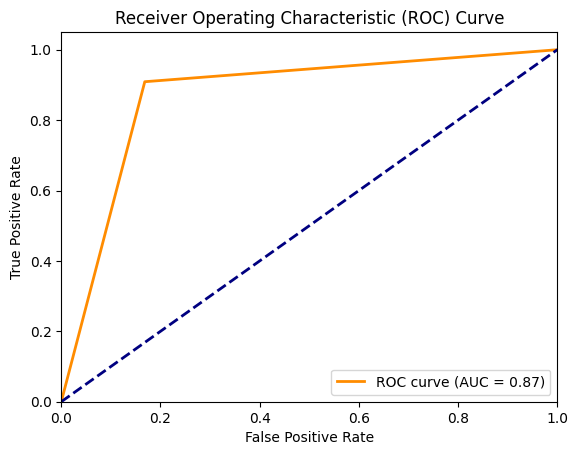

In [ ]:
from sklearn.metrics import roc_curve, auc

#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()